population parameters
Population Mean (mu): 12 
Population Variance (sigma^2): 6 

all possible samples and their means (Columns A, B, C)
  Value1 Value2 Sample_Mean
1      9      9         9.0
2     12      9        10.5
3     15      9        12.0
4      9     12        10.5
5     12     12        12.0
6     15     12        13.5
7      9     15        12.0
8     12     15        13.5
9     15     15        15.0

sampling dist table (Columns D, E, F, G)
  x_bar    p_xbar xbar_p_xbar xbar2_p_xbar
1   9.0 0.1111111    1.000000          9.0
2  10.5 0.2222222    2.333333         24.5
3  12.0 0.3333333    4.000000         48.0
4  13.5 0.2222222    3.000000         40.5
5  15.0 0.1111111    1.666667         25.0

final verification
Is Mean of Sampling Dist ( 12 ) == Population Mean ( 12 )?  TRUE 
Is Variance ( 3 ) == sigma^2 / n ( 3 )?  TRUE 
(a) & (b) Population Parameters 
Population Mean (mu): 9 
Population SD (sigma): 4.472136 

(c) & (d) Sampling Distribution Parameters
Mean of Sampli

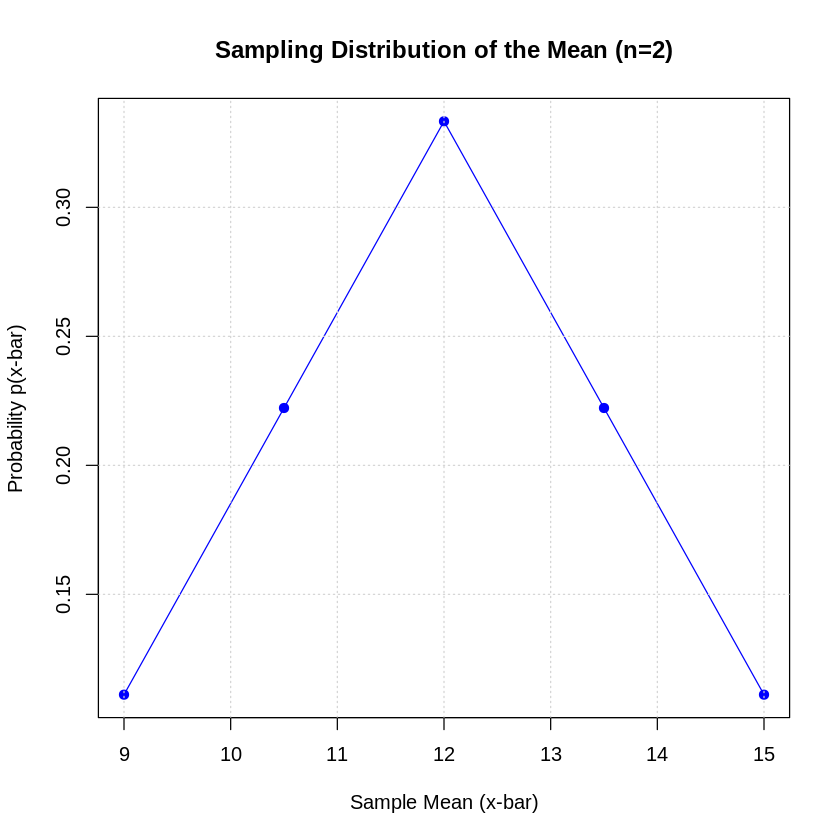

POPULATION PARAMETERSPopulation Mean (mu): 12 
Population Variance (sigma^2): 10.8 

FIRST 10 SAMPLES (out of 25)   x1 x2 Sample_Mean Sample_Prob
1   6  6         6.0        0.01
6   6  9         7.5        0.02
11  6 12         9.0        0.04
16  6 15        10.5        0.02
21  6 18        12.0        0.01
2   9  6         7.5        0.02
7   9  9         9.0        0.04
12  9 12        10.5        0.08
17  9 15        12.0        0.04
22  9 18        13.5        0.02

... (25 total samples generated) ...

--- 3. SAMPLING DISTRIBUTION OF THE MEAN ---
  Sample_Mean Sample_Prob
1         6.0        0.01
2         7.5        0.04
3         9.0        0.12
4        10.5        0.20
5        12.0        0.26
6        13.5        0.20
7        15.0        0.12
8        16.5        0.04
9        18.0        0.01

--- 4. VERIFICATION ---
Mean of Means: 12  (Should be 12 )
Var of Means: 5.4  (Should be 5.4 )


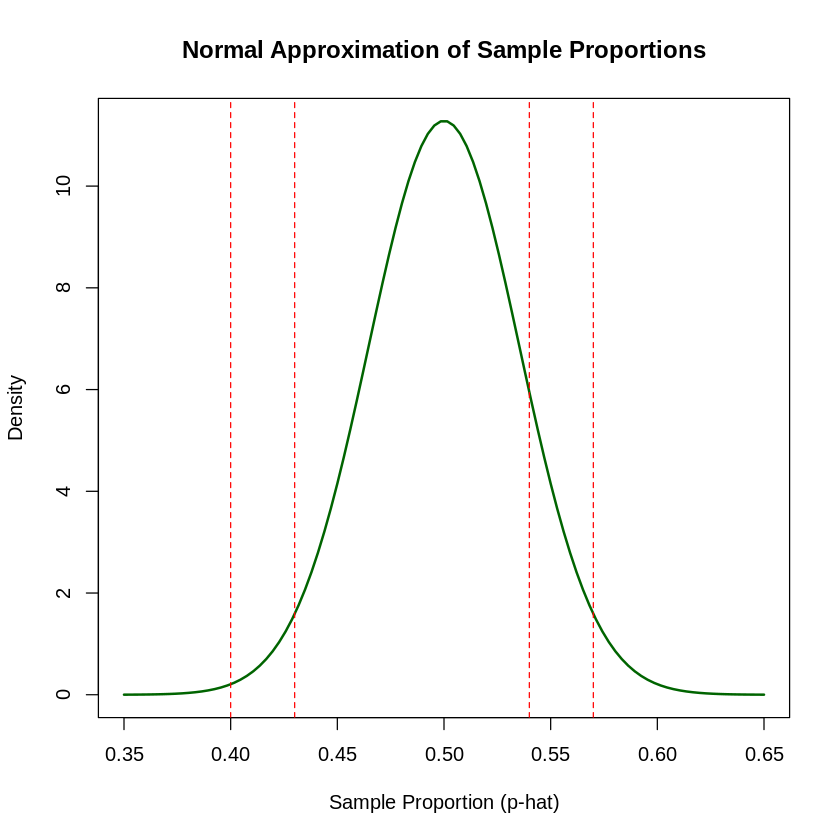

In [6]:
#8.18
population <- c(9, 12, 15)
n <- 2



mu <- mean(population)
sigma_sq <- sum((population - mu)^2) / length(population)

samples_table <- expand.grid(Value1 = population, Value2 = population)

samples_table$Sample_Mean <- rowMeans(samples_table)

sampling_dist <- as.data.frame(table(samples_table$Sample_Mean) / nrow(samples_table))
names(sampling_dist) <- c("x_bar", "p_xbar")

sampling_dist$x_bar <- as.numeric(as.character(sampling_dist$x_bar))

sampling_dist$xbar_p_xbar <- sampling_dist$x_bar * sampling_dist$p_xbar
sampling_dist$xbar2_p_xbar <- (sampling_dist$x_bar^2) * sampling_dist$p_xbar

mu_xbar <- sum(sampling_dist$xbar_p_xbar)
var_xbar <- sum(sampling_dist$xbar2_p_xbar) - (mu_xbar^2)

#OUTPUT

cat("population parameters\n")
cat("Population Mean (mu):", mu, "\n")
cat("Population Variance (sigma^2):", sigma_sq, "\n\n")

cat("all possible samples and their means (Columns A, B, C)\n")
print(samples_table)
cat("\n")

cat("sampling dist table (Columns D, E, F, G)\n")
print(sampling_dist)
cat("\n")

cat("final verification\n")
cat("Is Mean of Sampling Dist (", mu_xbar, ") == Population Mean (", mu, ")? ", mu_xbar == mu, "\n")
cat("Is Variance (", var_xbar, ") == sigma^2 / n (", sigma_sq/n, ")? ", var_xbar == (sigma_sq/n), "\n")

plot(sampling_dist$x_bar, sampling_dist$p_xbar, type="o", pch=19, col="blue",
     xlab="Sample Mean (x-bar)", ylab="Probability p(x-bar)",
     main="Sampling Distribution of the Mean (n=2)")
grid()



#8.21
pop <- c(3, 7, 11, 15)
n <- 2

mu <- mean(pop)

sigma <- sqrt(sum((pop - mu)^2) / length(pop))
samples_table <- expand.grid(X1 = pop, X2 = pop)

samples_table$x_bar <- rowMeans(as.matrix(samples_table))

sampling_dist <- as.data.frame(table(samples_table$x_bar) / nrow(samples_table))
names(sampling_dist) <- c("x_bar", "prob")
sampling_dist$x_bar <- as.numeric(as.character(sampling_dist$x_bar))

mu_xbar <- sum(sampling_dist$x_bar * sampling_dist$prob)

var_xbar <- sum(sampling_dist$x_bar^2 * sampling_dist$prob) - (mu_xbar^2)
sigma_xbar <- sqrt(var_xbar)



cat("(a) & (b) Population Parameters \n")
cat("Population Mean (mu):", mu, "\n")
cat("Population SD (sigma):", sigma, "\n\n")

cat("(c) & (d) Sampling Distribution Parameters\n")
cat("Mean of Sampling Dist (mu_xbar):", mu_xbar, "\n")
cat("SD of Sampling Dist (sigma_xbar):", sigma_xbar, "\n\n")

cat("Verification using Formulas\n")
cat("Does mu_xbar == mu?", all.equal(mu_xbar, mu), "\n")
cat("Does sigma_xbar == sigma / sqrt(n)?", all.equal(sigma_xbar, sigma / sqrt(n)), "\n")

cat("\n All 16 Possible Samples\n")
print(samples_table)


#8.34

n <- 200
p <- 0.5
q <- 1 - p

mu_p <- p
sigma_p <- sqrt((p * q) / n)

prob_a <- pnorm(0.40, mean = mu_p, sd = sigma_p)

prob_b <- pnorm(0.57, mean = mu_p, sd = sigma_p) - pnorm(0.43, mean = mu_p, sd = sigma_p)

prob_c <- 1 - pnorm(0.54, mean = mu_p, sd = sigma_p)

cat("Parameters\n")
cat("Mean (mu_p):", mu_p, "\n")
cat("Standard Error (sigma_p):", sigma_p, "\n\n")

cat("probabilities\n")
cat("(a) P(p < 0.40):", prob_a, "\n")
cat("(b) P(0.43 < p < 0.57):", prob_b, "\n")
cat("(c) P(p > 0.54):", prob_c, "\n")

x_vals <- seq(0.35, 0.65, length=100)
y_vals <- dnorm(x_vals, mean = mu_p, sd = sigma_p)
plot(x_vals, y_vals, type="l", lwd=2, col="darkgreen",
     main="Normal Approximation of Sample Proportions",
     xlab="Sample Proportion (p-hat)", ylab="Density")
abline(v = c(0.40, 0.43, 0.57, 0.54), col="red", lty=2)


#8.49

x <- c(6, 9, 12, 15, 18)
px <- c(0.1, 0.2, 0.4, 0.2, 0.1)

mu <- sum(x * px)
sigma_sq <- sum(x^2 * px) - mu^2

samples_table <- expand.grid(x1 = x, x2 = x)

prob_lookup <- data.frame(val = x, p = px)

samples_table <- merge(samples_table, prob_lookup, by.x = "x1", by.y = "val")
samples_table <- merge(samples_table, prob_lookup, by.x = "x2", by.y = "val")

samples_table$Sample_Mean <- (samples_table$x1 + samples_table$x2) / 2
samples_table$Sample_Prob <- samples_table$p.x * samples_table$p.y

sampling_dist <- aggregate(Sample_Prob ~ Sample_Mean, data = samples_table, sum)


cat("population parameter \n")
cat("Population Mean (mu):", mu, "\n")
cat("Population Variance (sigma^2):", sigma_sq, "\n\n")

cat("first 10 samples\n")
samples_table <- samples_table[order(samples_table$x1, samples_table$x2), ]
print(head(samples_table[, c("x1", "x2", "Sample_Mean", "Sample_Prob")], 10))
cat("\n... (25 total samples generated) ...\n\n")

cat("sampling dist of the mean\n")
print(sampling_dist)

mu_xbar <- sum(sampling_dist$Sample_Mean * sampling_dist$Sample_Prob)
var_xbar <- sum(sampling_dist$Sample_Mean^2 * sampling_dist$Sample_Prob) - mu_xbar^2

cat("verification\n")
cat("Mean of Means:", mu_xbar, " (Should be", mu, ")\n")
cat("Var of Means:", var_xbar, " (Should be", sigma_sq/2, ")\n")